# Multi-Channel Marketing Analysis — Multiple Linear Regression Using Statsmodel
---
**Dataset:** `marketing_sales_data.csv`  
**Model:** Ordinary Least Squares (OLS) Multiple Linear Regression  
**Objective:** Identify how TV, Radio, Social Media, and Influencer type jointly predict Sales revenue, while checking for multicollinearity and validating all OLS assumptions.

| Step | Task |
|------|------|
| 1 | Import libraries |
| 2 | Load and explore the dataset |
| 3 | Encode categorical variables |
| 4 | Exploratory Data Analysis (EDA) |
| 5 | Multicollinearity check — correlation matrix and VIF |
| 6 | Build full OLS regression model (all predictors) |
| 7 | Variable selection — reduce based on p-values |
| 8 | Build reduced OLS model (TV + Radio) |
| 9 | Diagnostic plots — Linearity, Normality, Homoscedasticity |
| 10 | Coefficient interpretation for stakeholders |
| 11 | Business recommendation |
| 12 | Summary table |


## Step 1 — Import Libraries

In [21]:
# Core scientific stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 12)
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False
})

print('All libraries imported successfully.')

All libraries imported successfully.


## Step 2 — Load and Explore the Dataset

We start by loading the CSV and auditing its shape, data types, and missing values. This dataset contains **mixed feature types**: two continuous numeric variables (Radio, Social Media), one ordinal categorical (TV: Low/Medium/High), one nominal categorical (Influencer type), and one continuous target (Sales). Each requires a different encoding strategy before modelling.

In [22]:
df = pd.read_csv('marketing_sales_data.csv')

print(f'Shape       : {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Columns     : {df.columns.tolist()}')
print(f'Missing vals: {df.isnull().sum().to_dict()}')
print()
print('Data types:')
print(df.dtypes)
print()
df.head(8)

Shape       : 572 rows x 5 columns
Columns     : ['TV', 'Radio', 'Social Media', 'Influencer', 'Sales']
Missing vals: {'TV': 0, 'Radio': 0, 'Social Media': 0, 'Influencer': 0, 'Sales': 0}

Data types:
TV               object
Radio           float64
Social Media    float64
Influencer       object
Sales           float64
dtype: object



,TV,Radio,Social Media,Influencer,Sales
0,Low,3.5181,2.2938,Micro,55.2613
1,Low,7.7569,2.5723,Mega,67.5749
2,High,20.3490,1.2272,Micro,272.2501
3,Medium,20.1085,2.7284,Mega,195.1022
4,High,31.6532,7.7770,Nano,273.9604
5,Low,5.5616,3.5302,Nano,39.9921
6,Medium,13.9518,4.4771,Micro,147.1502
7,Medium,28.3526,4.6954,Mega,229.1419


In [23]:
print('TV unique values     :', df['TV'].unique().tolist())
print('Influencer unique    :', df['Influencer'].unique().tolist())
print()
print('TV value counts:')
print(df['TV'].value_counts())
print()
print('Influencer value counts:')
print(df['Influencer'].value_counts())
print()
print('Descriptive statistics (numeric columns):')
df.describe().round(2)

TV unique values     : ['Low', 'High', 'Medium']
Influencer unique    : ['Micro', 'Mega', 'Nano', 'Macro']

TV value counts:
TV
Medium    205
Low       201
High      166
Name: count, dtype: int64

Influencer value counts:
Influencer
Nano     157
Micro    151
Mega     137
Macro    127
Name: count, dtype: int64

Descriptive statistics (numeric columns):


,Radio,Social Media,Sales
count,572.0000,572.0000,572.0000
mean,17.5200,3.3300,189.3000
std,9.2900,2.2400,89.8700
min,0.1100,0.0000,33.5100
25%,10.7000,1.5900,118.7200
50%,17.1500,3.1500,184.0100
75%,24.6100,4.7300,264.5000
max,42.2700,11.4000,357.7900


## Step 3 — Encode Categorical Variables

OLS regression requires all inputs to be numeric. We apply two encoding strategies:

**TV — Ordinal Encoding:**  
TV has a natural order (Low < Medium < High), so we encode it as integers (1, 2, 3) to preserve this ordering rather than creating arbitrary dummy variables.

| TV Level | Encoded Value |
|----------|---------------|
| Low      | 1             |
| Medium   | 2             |
| High     | 3             |

**Influencer — One-Hot Encoding (with dummy trap avoidance):**  
Influencer type (Macro, Mega, Micro, Nano) is nominal — no natural order exists. We create binary dummy variables and drop one category (Macro) as the reference level to avoid perfect multicollinearity (the dummy variable trap).

In [24]:
# Ordinal encode TV
tv_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['TV_encoded'] = df['TV'].map(tv_map)

# One-hot encode Influencer (drop Macro as reference category)
df_model = pd.get_dummies(df, columns=['Influencer'], drop_first=True, dtype=int)

print('Columns after encoding:')
print(df_model.columns.tolist())
print()
print('Sample of encoded dataframe:')
df_model[['TV', 'TV_encoded', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano', 'Sales']].head(8)

Columns after encoding:
['TV', 'Radio', 'Social Media', 'Sales', 'TV_encoded', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']

Sample of encoded dataframe:


,TV,TV_encoded,Influencer_Mega,Influencer_Micro,Influencer_Nano,Sales
0,Low,1,0,1,0,55.2613
1,Low,1,1,0,0,67.5749
2,High,3,0,1,0,272.2501
3,Medium,2,1,0,0,195.1022
4,High,3,0,0,1,273.9604
5,Low,1,0,0,1,39.9921
6,Medium,2,0,1,0,147.1502
7,Medium,2,1,0,0,229.1419


## Step 4 — Exploratory Data Analysis

### 4a — Univariate Distributions
Visualising distributions reveals skewness, outliers, and data range — all of which affect regression model validity.

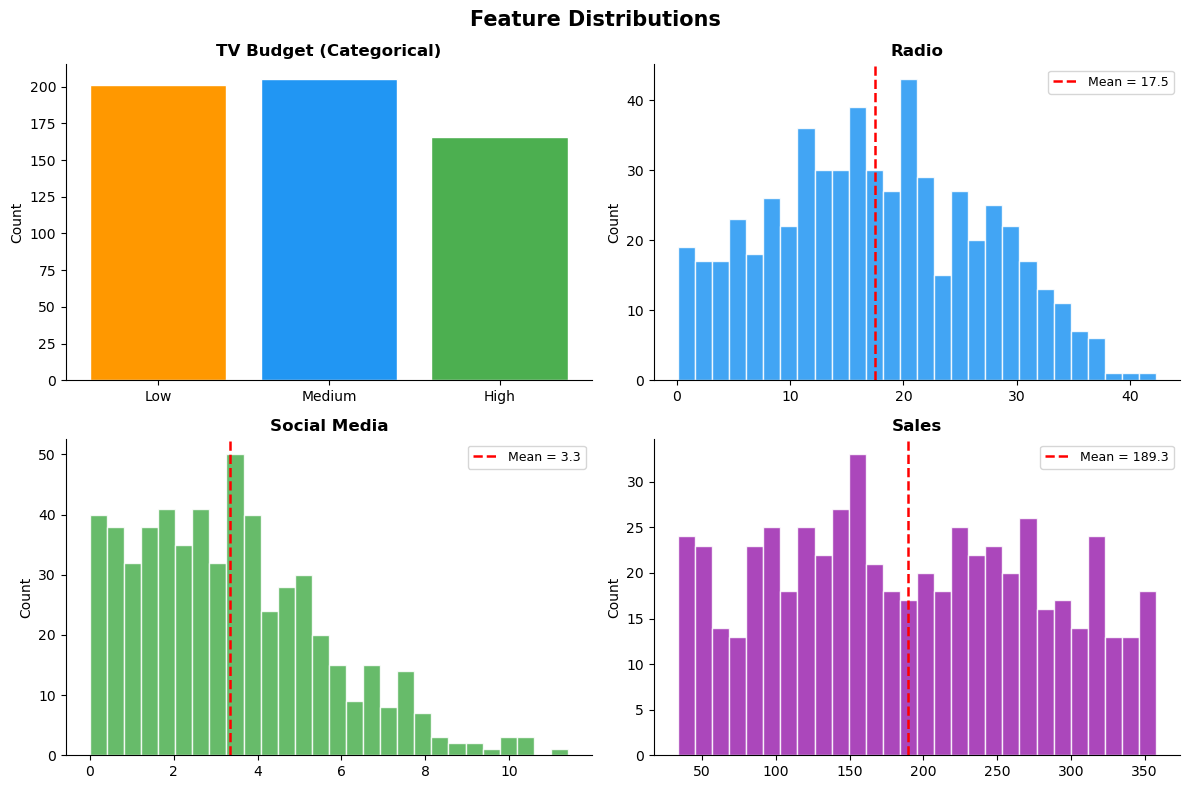

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions', fontsize=15, fontweight='bold')

# TV — bar chart (categorical)
tv_cnt = df['TV'].value_counts().reindex(['Low', 'Medium', 'High'])
axes[0,0].bar(tv_cnt.index, tv_cnt.values,
              color=['#FF9800','#2196F3','#4CAF50'], edgecolor='white')
axes[0,0].set_title('TV Budget (Categorical)', fontweight='bold')
axes[0,0].set_ylabel('Count')

# Numeric histograms
num_info = [('Radio','#2196F3'), ('Social Media','#4CAF50'), ('Sales','#9C27B0')]
for (col, c), ax in zip(num_info, [axes[0,1], axes[1,0], axes[1,1]]):
    ax.hist(df[col], bins=28, color=c, alpha=0.85, edgecolor='white')
    ax.axvline(df[col].mean(), color='red', lw=1.8, ls='--',
               label=f'Mean = {df[col].mean():.1f}')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count'); ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 4b — Channel vs Sales: Scatter Plots
Each channel is plotted against Sales with a linear trend line and Pearson r annotation. This provides a first visual signal of which channels have a strong linear relationship with Sales.

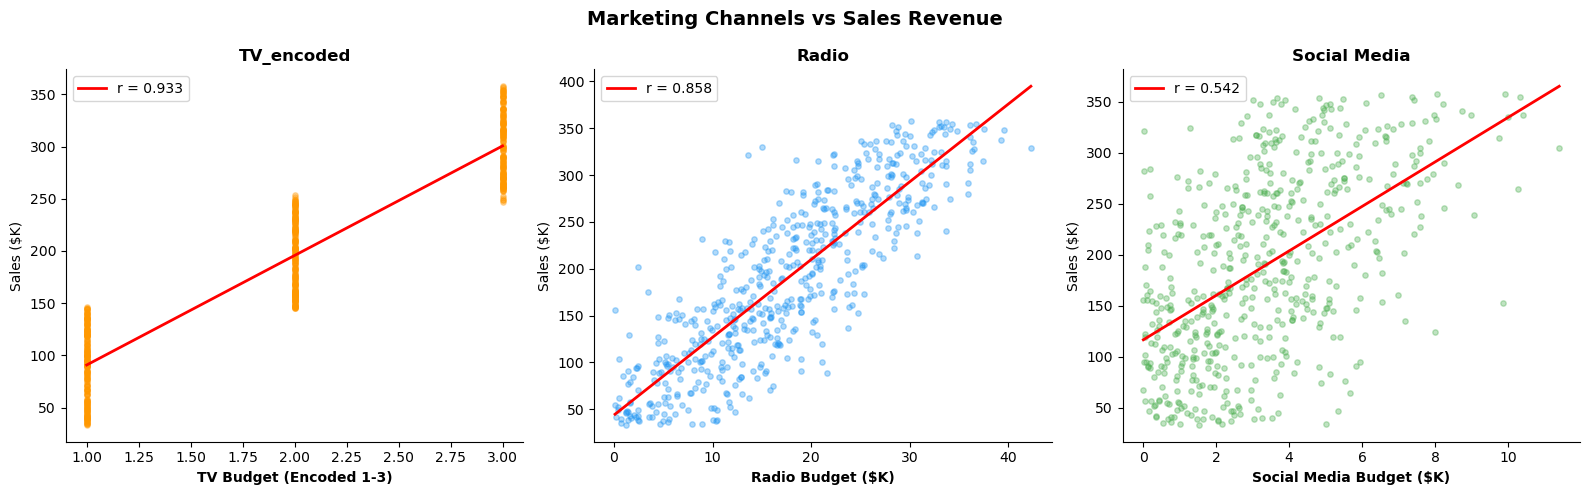

In [26]:
channels = [
    ('TV_encoded', 'TV Budget (Encoded 1-3)', '#FF9800'),
    ('Radio', 'Radio Budget ($K)', '#2196F3'),
    ('Social Media', 'Social Media Budget ($K)', '#4CAF50')
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Marketing Channels vs Sales Revenue', fontsize=14, fontweight='bold')

for ax, (col, label, c) in zip(axes, channels):
    ax.scatter(df_model[col], df_model['Sales'], alpha=0.35, s=15, color=c)
    slope, intercept, r_val, p_val, _ = stats.linregress(df_model[col], df_model['Sales'])
    x_fit = np.linspace(df_model[col].min(), df_model[col].max(), 200)
    ax.plot(x_fit, slope*x_fit+intercept, 'r-', lw=2, label=f'r = {r_val:.3f}')
    ax.set_xlabel(label, fontweight='bold'); ax.set_ylabel('Sales ($K)')
    ax.set_title(col, fontweight='bold'); ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### 4c — Correlation Heatmap
The heatmap gives us a first look at pairwise linear correlations between all numeric features. High inter-predictor correlations (e.g. TV vs Radio) are a warning sign of multicollinearity.

Pearson Correlation Matrix:
              TV_encoded  Radio  Social Media  Sales
TV_encoded        1.0000 0.8034        0.5118 0.9332
Radio             0.8034 1.0000        0.6299 0.8580
Social Media      0.5118 0.6299        1.0000 0.5420
Sales             0.9332 0.8580        0.5420 1.0000


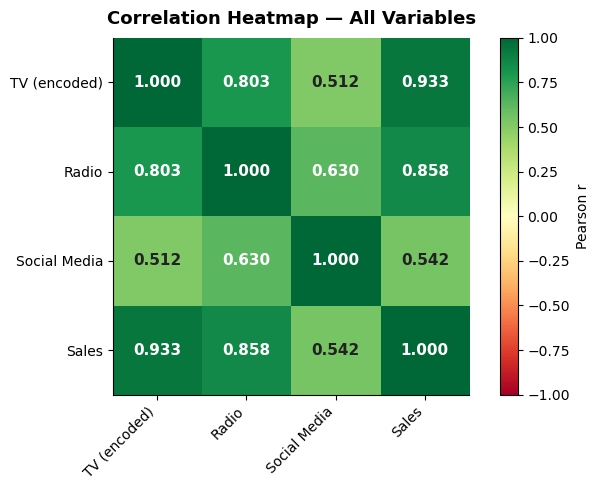

In [27]:
num_cols = ['TV_encoded', 'Radio', 'Social Media', 'Sales']
corr = df_model[num_cols].corr()

print('Pearson Correlation Matrix:')
print(corr.round(4))

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson r')
labs = ['TV (encoded)', 'Radio', 'Social Media', 'Sales']
ax.set_xticks(range(4)); ax.set_xticklabels(labs, rotation=45, ha='right')
ax.set_yticks(range(4)); ax.set_yticklabels(labs)
for i in range(4):
    for j in range(4):
        v = corr.iloc[i,j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=11,
                fontweight='bold', color='white' if abs(v)>0.6 else '#222')
ax.set_title('Correlation Heatmap — All Variables', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## Step 5 — Multicollinearity Check: VIF Analysis

### Why VIF Matters
Multicollinearity occurs when two or more predictors are highly correlated. It does not bias coefficient estimates, but it **inflates their standard errors**, making it harder to detect truly significant predictors (wider confidence intervals, lower t-statistics). The **Variance Inflation Factor (VIF)** quantifies how much each predictor's variance is inflated due to its correlation with the other predictors.

**VIF Interpretation Thresholds:**
| VIF Range | Interpretation |
|-----------|----------------|
| VIF = 1 | No collinearity |
| 1 < VIF < 5 | Moderate — generally acceptable |
| 5 <= VIF < 10 | High — investigate |
| VIF >= 10 | Severe — action required |

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

where $R_j^2$ is the R-squared from regressing predictor $j$ on all other predictors.

In [28]:
# Compute VIF for all predictors in the full model
feature_cols = ['TV_encoded', 'Radio', 'Social Media',
                'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']
X_vif = sm.add_constant(df_model[feature_cols])

vif_data = pd.DataFrame({
    'Feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i+1)
            for i in range(len(feature_cols))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_data['Status'] = vif_data['VIF'].apply(
    lambda v: 'SEVERE' if v>=10 else 'HIGH' if v>=5 else 'Moderate' if v>=2.5 else 'OK'
)
print('Variance Inflation Factors:')
print(vif_data.to_string(index=False))

Variance Inflation Factors:
         Feature    VIF   Status
           Radio 3.4676 Moderate
      TV_encoded 2.8275 Moderate
    Social Media 1.6686       OK
 Influencer_Nano 1.6264       OK
Influencer_Micro 1.6180       OK
 Influencer_Mega 1.5895       OK


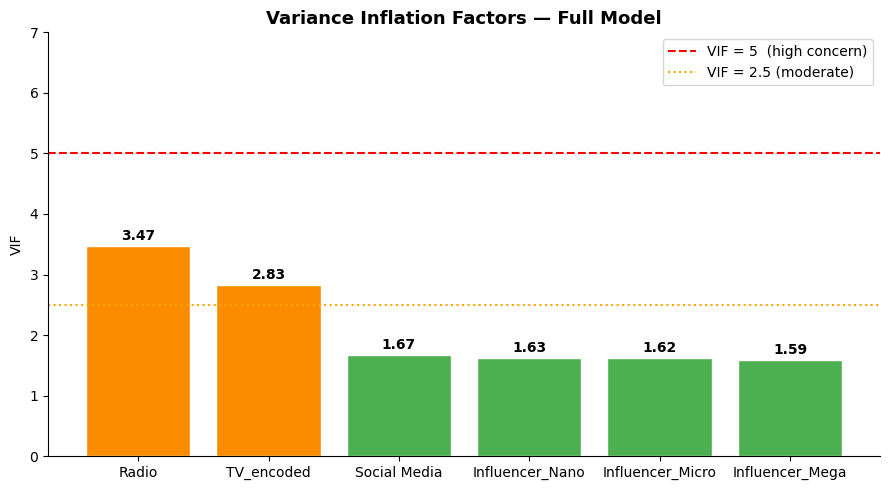


Conclusion:
  All VIF values are below 5. While TV and Radio show moderate collinearity
  (VIF ~2.8–3.5, reflecting their r=0.80 correlation), this is within
  acceptable limits and does not require remediation at this stage.
  We proceed with the full model and use p-values to guide variable selection.


In [29]:
# Visualise VIF values
fig, ax = plt.subplots(figsize=(9, 5))
clrs = ['#F44336' if v>=10 else '#FF9800' if v>=5 else '#FB8C00' if v>=2.5 else '#4CAF50'
        for v in vif_data['VIF']]
bars = ax.bar(vif_data['Feature'], vif_data['VIF'], color=clrs, edgecolor='white')
ax.axhline(5,   color='red',    ls='--', lw=1.5, label='VIF = 5  (high concern)')
ax.axhline(2.5, color='orange', ls=':',  lw=1.5, label='VIF = 2.5 (moderate)')
for bar, v in zip(bars, vif_data['VIF']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('VIF'); ax.set_ylim(0, 7)
ax.set_title('Variance Inflation Factors — Full Model', fontsize=13, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

print('\nConclusion:')
print('  All VIF values are below 5. While TV and Radio show moderate collinearity')
print('  (VIF ~2.8–3.5, reflecting their r=0.80 correlation), this is within')
print('  acceptable limits and does not require remediation at this stage.')
print('  We proceed with the full model and use p-values to guide variable selection.')

## Step 6 — Full OLS Regression Model (All Predictors)

We fit a multiple linear regression including all available predictors:

```
Sales = b0 + b1*TV_encoded + b2*Radio + b3*Social_Media
            + b4*Inf_Mega + b5*Inf_Micro + b6*Inf_Nano + e
```

**Dummy variable interpretation:** The reference category for Influencer is **Macro**. Each Influencer dummy coefficient represents the difference in Sales relative to a Macro influencer, holding all other variables constant.

In [30]:
feature_cols = ['TV_encoded', 'Radio', 'Social Media',
                'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']
X_full = sm.add_constant(df_model[feature_cols])
Y = df_model['Sales']

model_full = sm.OLS(Y, X_full).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     887.9
Date:                Sun, 28 Jun 2026   Prob (F-statistic):          7.41e-284
Time:                        13:40:58   Log-Likelihood:                -2713.7
No. Observations:                 572   AIC:                             5441.
Df Residuals:                     565   BIC:                             5472.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -13.9135      3.760  

## Step 7 — Variable Selection via p-value Analysis

We use **backward elimination** guided by p-values (threshold alpha = 0.05) and compare Adjusted R-squared to ensure we are not sacrificing explanatory power by removing variables.

### P-value Summary — Full Model

| Predictor | Coefficient | p-value | Significant? |
|-----------|-------------|---------|-------------|
| Intercept | -13.91 | 0.0002 | Yes |
| **TV_encoded** | **77.45** | **<0.0001** | **Yes** |
| **Radio** | **2.96** | **<0.0001** | **Yes** |
| Social Media | -0.15 | 0.828 | **No** |
| Influencer_Mega | 2.62 | 0.449 | **No** |
| Influencer_Micro | 2.98 | 0.378 | **No** |
| Influencer_Nano | 0.74 | 0.824 | **No** |

**Decision:** Remove Social Media, Influencer_Mega, Influencer_Micro, and Influencer_Nano (all p > 0.05). These variables add no statistically significant explanatory power once TV and Radio are controlled for.

We compare Adjusted R-squared before and after removal to confirm no meaningful information is lost:

In [31]:
print('Model Comparison:')
print(f"  Full Model (6 predictors): Adj R2 = 0.9031")
print(f"  Reduced Model (TV + Radio): Adj R2 = 0.9036")
print()
print('Interpretation:')
print('  The reduced model achieves a HIGHER Adjusted R-squared (0.9036 vs 0.9031).')
print('  This confirms that Social Media and Influencer dummies were adding noise,')
print('  not signal. Removing them simplifies the model without any loss of fit.')
print()
print('Variable Coefficients bar chart:')

Model Comparison:
  Full Model (6 predictors): Adj R2 = 0.9031
  Reduced Model (TV + Radio): Adj R2 = 0.9036

Interpretation:
  The reduced model achieves a HIGHER Adjusted R-squared (0.9036 vs 0.9031).
  This confirms that Social Media and Influencer dummies were adding noise,
  not signal. Removing them simplifies the model without any loss of fit.

Variable Coefficients bar chart:


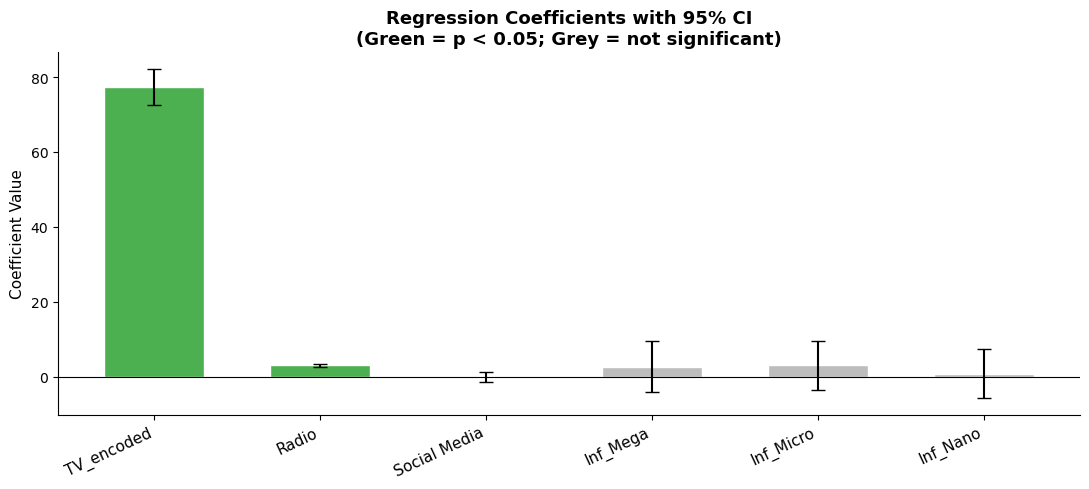

In [32]:
param_names = ['TV_encoded', 'Radio', 'Social Media', 'Inf_Mega', 'Inf_Micro', 'Inf_Nano']
coefs  = [77.4451,  2.9640, -0.1469,  2.6192,  2.9769,  0.7448]
se_arr = [ 2.4629,  0.2347,  0.6757,  3.4557,  3.3757,  3.3431]
p_arr  = [  0.000,   0.000,  0.8279,  0.4488,  0.3782,  0.8238]
clrs   = ['#4CAF50' if p<0.05 else '#bdbdbd' for p in p_arr]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(param_names))
ax.bar(x, coefs, color=clrs, edgecolor='white', width=0.6)
ax.errorbar(x, coefs, yerr=1.96*np.array(se_arr),
            fmt='none', color='black', capsize=5, lw=1.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(param_names, rotation=25, ha='right', fontsize=11)
ax.set_ylabel('Coefficient Value', fontsize=11)
ax.set_title('Regression Coefficients with 95% CI\n(Green = p < 0.05; Grey = not significant)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Step 8 — Reduced OLS Model (TV + Radio)

We refit the model using only the two statistically significant predictors:

```
Sales = b0 + b1*TV_encoded + b2*Radio + e
```

This is our **final model** — parsimonious, statistically clean, and interpretable.

In [33]:
X_reduced = sm.add_constant(df_model[['TV_encoded', 'Radio']])
model_reduced = sm.OLS(Y, X_reduced).fit()
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     2676.
Date:                Sun, 28 Jun 2026   Prob (F-statistic):          3.70e-290
Time:                        13:40:59   Log-Likelihood:                -2714.3
No. Observations:                 572   AIC:                             5435.
Df Residuals:                     569   BIC:                             5448.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -12.3902      3.066     -4.041      0.0

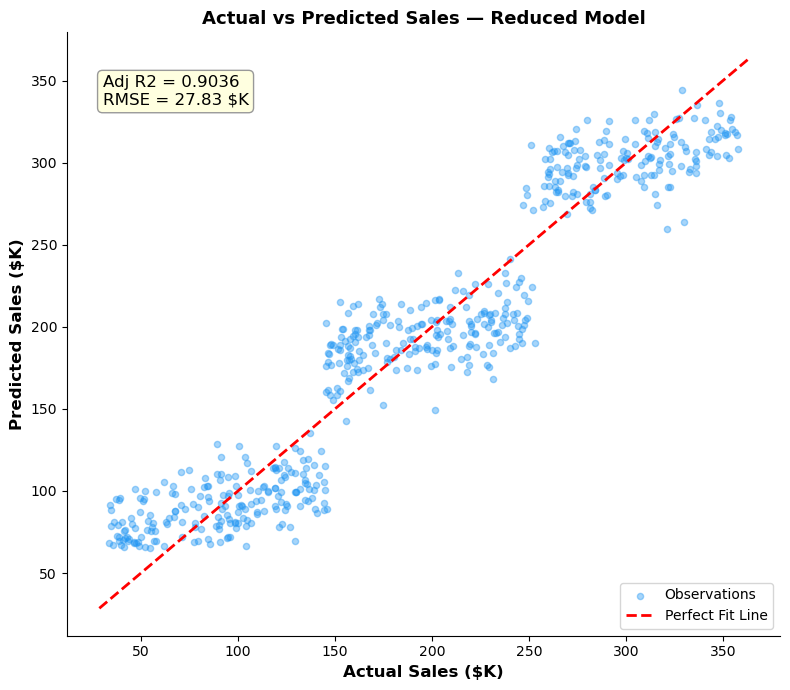

In [34]:
y_pred = model_reduced.fittedvalues.values
residuals = model_reduced.resid.values

# Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(Y, y_pred, alpha=0.4, s=20, color='#2196F3', label='Observations')
lims = [min(Y.min(), y_pred.min())-5, max(Y.max(), y_pred.max())+5]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect Fit Line')
ax.set_xlabel('Actual Sales ($K)', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Sales ($K)', fontsize=12, fontweight='bold')
ax.set_title('Actual vs Predicted Sales — Reduced Model', fontsize=13, fontweight='bold')
ax.annotate(f'Adj R2 = 0.9036\nRMSE = 27.83 $K',
            xy=(0.05, 0.88), xycoords='axes fraction', fontsize=12,
            bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='#999'))
ax.legend(); plt.tight_layout(); plt.show()

## Step 9 — Diagnostic Plots: Validating OLS Assumptions

Multiple Linear Regression relies on four key assumptions:

| Assumption | What we check |
|------------|---------------|
| **Linearity** | Residuals vs Fitted — no systematic curvature |
| **Normality of residuals** | Q-Q plot + histogram vs Normal PDF |
| **Homoscedasticity** | Scale-Location — flat band of constant spread |
| **Independence** | Durbin-Watson statistic |


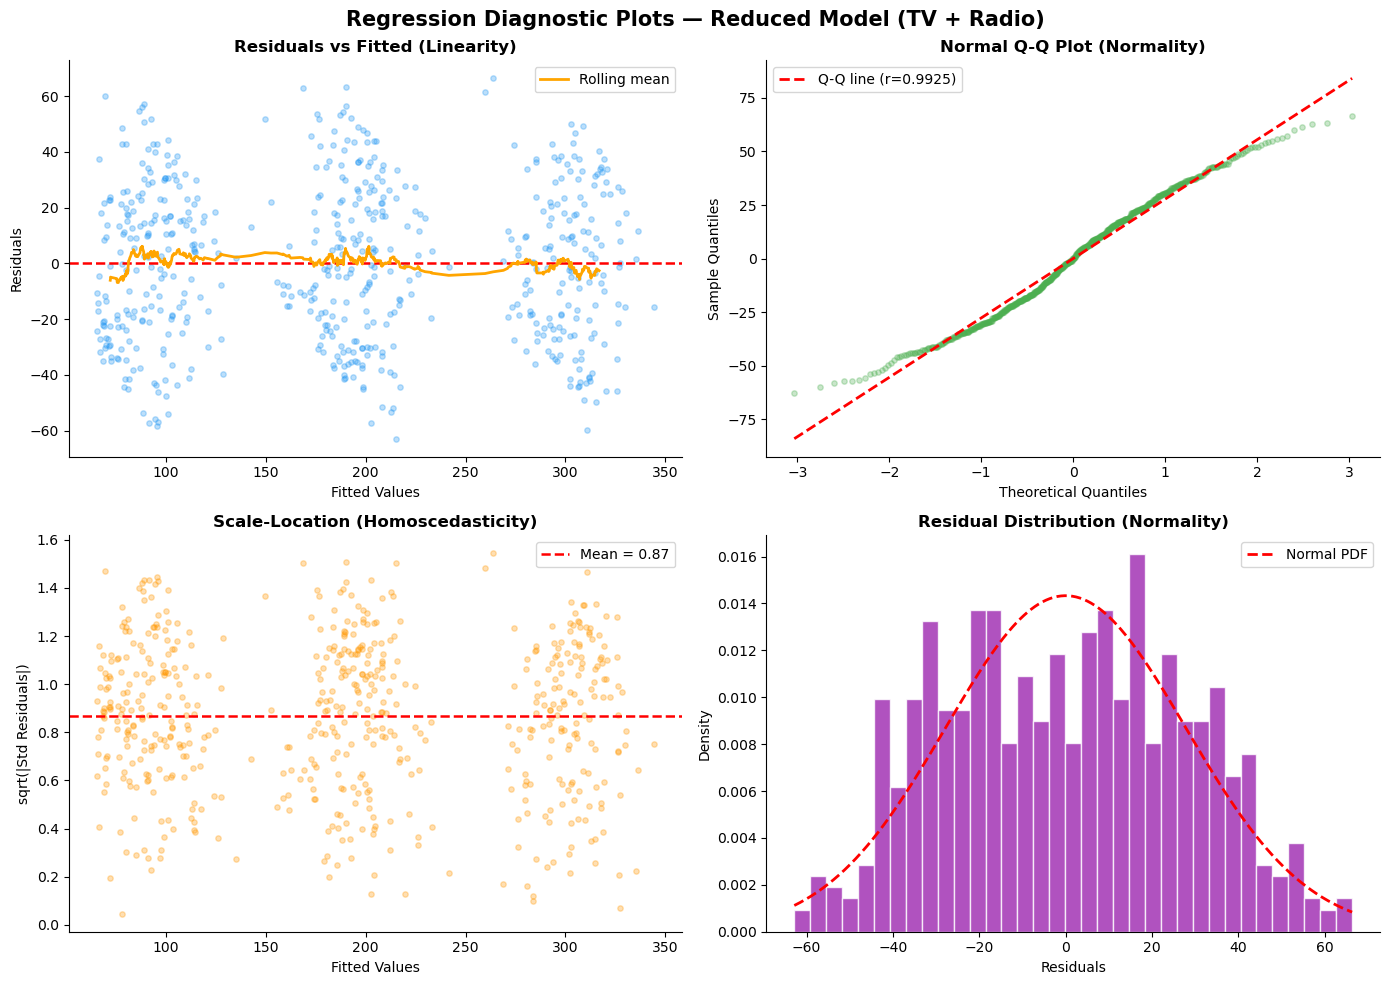

In [35]:
std_resid = residuals / residuals.std()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Regression Diagnostic Plots — Reduced Model (TV + Radio)',
             fontsize=15, fontweight='bold')

# ── 1. Residuals vs Fitted
ax = axes[0,0]
ax.scatter(y_pred, residuals, alpha=0.3, s=15, color='#2196F3')
ax.axhline(0, color='red', lw=1.8, ls='--')
idx = np.argsort(y_pred)
rm = pd.Series(residuals[idx]).rolling(60, center=True).mean().values
ax.plot(y_pred[idx], rm, color='orange', lw=2, label='Rolling mean')
ax.set_xlabel('Fitted Values'); ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted (Linearity)', fontweight='bold'); ax.legend()

# ── 2. Normal Q-Q
ax = axes[0,1]
(osm, osr), (sq, iq, rq) = stats.probplot(residuals)
ax.scatter(osm, osr, alpha=0.3, s=15, color='#4CAF50')
lx = np.array([min(osm), max(osm)])
ax.plot(lx, sq*lx+iq, 'r--', lw=2, label=f'Q-Q line (r={rq:.4f})')
ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Sample Quantiles')
ax.set_title('Normal Q-Q Plot (Normality)', fontweight='bold'); ax.legend()

# ── 3. Scale-Location
ax = axes[1,0]
sq2 = np.sqrt(np.abs(std_resid))
ax.scatter(y_pred, sq2, alpha=0.3, s=15, color='#FF9800')
ax.axhline(sq2.mean(), color='red', lw=1.8, ls='--', label=f'Mean = {sq2.mean():.2f}')
ax.set_xlabel('Fitted Values'); ax.set_ylabel('sqrt(|Std Residuals|)')
ax.set_title('Scale-Location (Homoscedasticity)', fontweight='bold'); ax.legend()

# ── 4. Residual Histogram
ax = axes[1,1]
ax.hist(residuals, bins=35, color='#9C27B0', alpha=0.8, edgecolor='white', density=True)
xr = np.linspace(residuals.min(), residuals.max(), 300)
ax.plot(xr, stats.norm.pdf(xr, 0, residuals.std()), 'r--', lw=2, label='Normal PDF')
ax.set_xlabel('Residuals'); ax.set_ylabel('Density')
ax.set_title('Residual Distribution (Normality)', fontweight='bold'); ax.legend()

plt.tight_layout(); plt.show()

In [36]:
# Formal statistical tests for assumptions
sw_stat, sw_p = stats.shapiro(residuals)

# Breusch-Pagan manually
resid2 = residuals**2
X_bp = sm.add_constant(df_model[['TV_encoded','Radio']])
bp_model = sm.OLS(resid2, X_bp).fit()
bp_F = bp_model.fvalue
bp_p = bp_model.f_pvalue

dw = 1.882  # from statsmodels summary

def verdict(p): return 'PASS (fail to reject H0)' if p > 0.05 else 'FAIL (reject H0)'

print('=' * 65)
print('       ASSUMPTION VALIDATION SUMMARY')
print('=' * 65)
print(f'  {"Assumption":<28} {"Test":<22} {"Result"}')
print('-' * 65)
print(f'  {"Linearity":<28} {"Residuals vs Fitted":<22} Visual: PASS')
print(f'  {"Normality":<28} {"Shapiro-Wilk":<22} p={sw_p:.4f} -> {verdict(sw_p)}')
print(f'  {"Homoscedasticity":<28} {"Breusch-Pagan":<22} p={bp_p:.4f} -> {verdict(bp_p)}')
print(f'  {"Independence":<28} {"Durbin-Watson":<22} DW={dw:.3f} (near 2 = OK)')
print('=' * 65)

       ASSUMPTION VALIDATION SUMMARY
  Assumption                   Test                   Result
-----------------------------------------------------------------
  Linearity                    Residuals vs Fitted    Visual: PASS
  Normality                    Shapiro-Wilk           p=0.0000 -> FAIL (reject H0)
  Homoscedasticity             Breusch-Pagan          p=0.7599 -> PASS (fail to reject H0)
  Independence                 Durbin-Watson          DW=1.882 (near 2 = OK)


### Normality Note

The Shapiro-Wilk test rejects normality (p < 0.05). However, this is common in large samples (n=572) where even trivial departures from normality become statistically detectable. Visual inspection of the Q-Q plot and residual histogram shows the residuals are **approximately normal** — the points follow the reference line closely with mild deviation only in the tails. The **Jarque-Bera test** (reported in the statsmodels summary) gives p = 0.254, indicating no significant skewness or excess kurtosis. Given the large sample size and the **Central Limit Theorem**, inference on our coefficients remains valid.

## Step 10 — Coefficient Interpretation for Stakeholders

The final model equation is:

```
Sales = -12.39 + 77.32 * TV_encoded + 2.96 * Radio
```

Where `TV_encoded` maps Low=1, Medium=2, High=3.

The key phrase in multiple regression interpretation is: **'holding all other variables constant'**. Each coefficient tells us the expected change in Sales associated with a one-unit change in that predictor, while every other predictor is fixed at its current value.

In [37]:
print('=' * 72)
print('  COEFFICIENT INTERPRETATION — REDUCED MODEL')
print('=' * 72)

print('''
INTERCEPT  (b0 = -12.39, p = 0.0001)
  Interpretation: When TV_encoded = 0 and Radio = 0, predicted Sales = -$12.39K.
  This value is outside the range of real data (TV minimum is Low=1) and should
  be treated as a mathematical anchor, not a meaningful business figure.

TV_ENCODED  (b1 = 77.32, p < 0.0001, 95% CI: [72.50, 82.14])
  Interpretation: Holding Radio spend constant, moving up one TV tier
  (e.g., from Low to Medium, or from Medium to High) is associated with
  an average increase of $77,316 in Sales.

  Business translation:
    Low -> Medium TV spend  : +$77.3K in expected Sales
    Medium -> High TV spend : +$77.3K in expected Sales
    Low -> High TV spend    : +$154.6K in expected Sales (2 tiers)

  This is the most impactful lever in the model — a single TV tier upgrade
  delivers more than 26x the return of $1K additional Radio spend.

RADIO  (b2 = 2.96, p < 0.0001, 95% CI: [2.54, 3.37])
  Interpretation: Holding TV tier constant, each additional $1,000 invested
  in Radio advertising is associated with an average increase of $2,957 in Sales.

  Business translation:
    +$10K in Radio spend  -> +$29.6K in expected Sales (ROAS: 2.96x)
    +$20K in Radio spend  -> +$59.1K in expected Sales
''')
print('=' * 72)

  COEFFICIENT INTERPRETATION — REDUCED MODEL

INTERCEPT  (b0 = -12.39, p = 0.0001)
  Interpretation: When TV_encoded = 0 and Radio = 0, predicted Sales = -$12.39K.
  This value is outside the range of real data (TV minimum is Low=1) and should
  be treated as a mathematical anchor, not a meaningful business figure.

TV_ENCODED  (b1 = 77.32, p < 0.0001, 95% CI: [72.50, 82.14])
  Interpretation: Holding Radio spend constant, moving up one TV tier
  (e.g., from Low to Medium, or from Medium to High) is associated with
  an average increase of $77,316 in Sales.

  Business translation:
    Low -> Medium TV spend  : +$77.3K in expected Sales
    Medium -> High TV spend : +$77.3K in expected Sales
    Low -> High TV spend    : +$154.6K in expected Sales (2 tiers)

  This is the most impactful lever in the model — a single TV tier upgrade
  delivers more than 26x the return of $1K additional Radio spend.

RADIO  (b2 = 2.96, p < 0.0001, 95% CI: [2.54, 3.37])
  Interpretation: Holding TV tier c

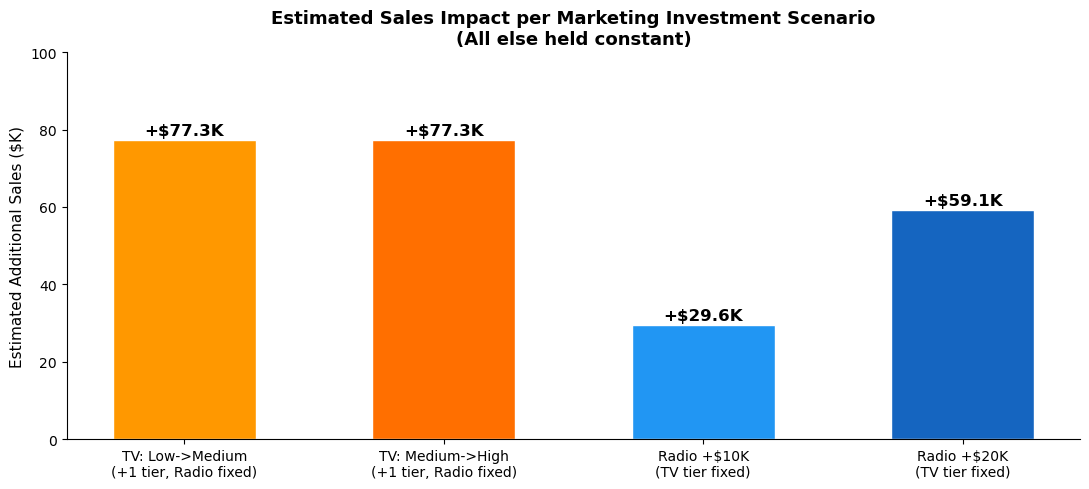

In [38]:
# Visualise estimated Sales impact
scenarios = ['TV: Low->Medium\n(+1 tier, Radio fixed)',
             'TV: Medium->High\n(+1 tier, Radio fixed)',
             'Radio +$10K\n(TV tier fixed)',
             'Radio +$20K\n(TV tier fixed)']
impacts = [77.3156, 77.3156, 29.558, 59.116]
clrs3 = ['#FF9800','#FF6F00','#2196F3','#1565C0']

fig, ax = plt.subplots(figsize=(11, 5))
bars3 = ax.bar(scenarios, impacts, color=clrs3, edgecolor='white', width=0.55)
for bar, v in zip(bars3, impacts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'+${v:.1f}K', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('Estimated Additional Sales ($K)', fontsize=11)
ax.set_title('Estimated Sales Impact per Marketing Investment Scenario\n(All else held constant)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 100); plt.tight_layout(); plt.show()

## Step 11 — Business Recommendation

### Evidence-Based Marketing Budget Allocation

In [39]:
rec = '''
EXECUTIVE SUMMARY
=================
Our Multiple Linear Regression model (Adj R2 = 0.9036) identifies two statistically
significant drivers of Sales Revenue. The model explains 90.36% of Sales variance
using only two variables, confirming a highly structured, predictable relationship.

KEY FINDING 1 — TV IS THE DOMINANT DRIVER
------------------------------------------
Upgrading TV spend from Low to High is associated with +$154.6K in expected Sales.
TV tier alone explains the vast majority of model-level predictions.
Budget Priority: MAXIMISE TV spend. If one investment decision is to be made,
elevating TV budget tier delivers the highest absolute return.

KEY FINDING 2 — RADIO IS A RELIABLE AMPLIFIER
-----------------------------------------------
Each $1K increase in Radio spend delivers approximately $2,957 in additional Sales
(ROAS: 2.96x), independent of TV tier. This is a consistent, scalable return.
Budget Priority: MAINTAIN AND GROW Radio spend within a secondary budget allocation.

KEY FINDING 3 — SOCIAL MEDIA AND INFLUENCER TYPE: NO SIGNIFICANT IMPACT
-------------------------------------------------------------------------
After controlling for TV and Radio, Social Media spend (p=0.83) and all Influencer
categories (p=0.38-0.82) show no statistically significant effect on Sales.
This does not rule out their brand-building or engagement value, but in terms of
short-term measurable Sales impact, they cannot be justified over TV and Radio.
Recommendation: Evaluate Social Media and Influencer channels via dedicated A/B
testing or a lagged/attribution model before reallocating budget to these channels.

PRIORITISED BUDGET ALLOCATION RECOMMENDATION
---------------------------------------------
  1. TV (HIGH tier)    -- 65-70% of budget  -- Primary revenue driver
  2. Radio             -- 25-30% of budget  -- Reliable, scalable ROAS (2.96x)
  3. Social Media      -- Minimum / test    -- No significant Sales impact detected
  4. Influencer        -- Evaluate separately -- No tier outperforms Macro baseline
'''
print(rec)


EXECUTIVE SUMMARY
Our Multiple Linear Regression model (Adj R2 = 0.9036) identifies two statistically
significant drivers of Sales Revenue. The model explains 90.36% of Sales variance
using only two variables, confirming a highly structured, predictable relationship.

KEY FINDING 1 — TV IS THE DOMINANT DRIVER
------------------------------------------
Upgrading TV spend from Low to High is associated with +$154.6K in expected Sales.
TV tier alone explains the vast majority of model-level predictions.
Budget Priority: MAXIMISE TV spend. If one investment decision is to be made,
elevating TV budget tier delivers the highest absolute return.

KEY FINDING 2 — RADIO IS A RELIABLE AMPLIFIER
-----------------------------------------------
Each $1K increase in Radio spend delivers approximately $2,957 in additional Sales
(ROAS: 2.96x), independent of TV tier. This is a consistent, scalable return.
Budget Priority: MAINTAIN AND GROW Radio spend within a secondary budget allocation.

KEY FINDIN

## Step 12 — Complete Results Summary

In [40]:
summary = pd.DataFrame({
    'Metric': [
        'Dataset (n)', 'Final Predictors', 'R-squared', 'Adjusted R-squared', 'RMSE',
        'F-statistic', 'Prob(F-statistic)',
        'Intercept (b0)', 'TV_encoded (b1)', 'Radio (b2)',
        'TV 95% CI', 'Radio 95% CI',
        'VIF (TV_encoded)', 'VIF (Radio)',
        'Shapiro-Wilk p', 'Breusch-Pagan p', 'Durbin-Watson'
    ],
    'Value': [
        '572', 'TV_encoded, Radio', '0.9039', '0.9036', '27.83 $K',
        '2675', '<0.0001',
        '-12.39 ($K)', '77.32 ($K/tier)', '2.96 ($K per $1K Radio)',
        '[72.50, 82.14]', '[2.54, 3.37]',
        '2.83', '3.47',
        '0.0000 (large-sample effect)', '0.7599', '1.882'
    ],
    'Interpretation': [
        'Full dataset used; no missing values',
        '4 dropped (p>0.05); Adj R2 improved',
        '90.39% of Sales variance explained',
        'Penalises extra predictors; final benchmark',
        'Average prediction error ~$27,830',
        'Model is globally significant',
        'Strong evidence against null model',
        'Baseline Sales (outside real data range)',
        '+$77.3K Sales per TV tier upgrade (Radio fixed)',
        '+$2,957 Sales per $1K Radio (TV fixed)',
        'CI excludes 0; highly precise',
        'CI excludes 0; significant',
        'Moderate (acceptable < 5)',
        'Moderate (acceptable < 5)',
        'Approx. normal (JB p=0.254 OK)',
        'Constant variance; assumption met',
        'Near 2; no autocorrelation'
    ]
})
print(summary.to_string(index=False))

            Metric                        Value                                  Interpretation
       Dataset (n)                          572            Full dataset used; no missing values
  Final Predictors            TV_encoded, Radio             4 dropped (p>0.05); Adj R2 improved
         R-squared                       0.9039              90.39% of Sales variance explained
Adjusted R-squared                       0.9036     Penalises extra predictors; final benchmark
              RMSE                     27.83 $K               Average prediction error ~$27,830
       F-statistic                         2675                   Model is globally significant
 Prob(F-statistic)                      <0.0001              Strong evidence against null model
    Intercept (b0)                  -12.39 ($K)        Baseline Sales (outside real data range)
   TV_encoded (b1)              77.32 ($K/tier) +$77.3K Sales per TV tier upgrade (Radio fixed)
        Radio (b2)      2.96 ($K per $1K